# Farm Cartoon Video Pipeline
Run this notebook on Google Colab with a GPU runtime.
**Runtime > Change runtime type > T4 GPU**

In [ ]:
# Step 1 — Install dependencies
!pip install -q git+https://github.com/huggingface/diffusers.git
!pip install -q transformers accelerate peft torch huggingface_hub prodigyopt torchao sentencepiece
print("Done!")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.1/509.1 kB 18.1 MB/s eta 0:00:00
Done!


In [ ]:
from google.colab import userdata
from huggingface_hub import login

login(userdata.get("HF_TOKEN"))

In [ ]:
!ls "/content/drive/MyDrive/Independent Study ML Diffusion/my_cartoon_lora"

lora_output


In [ ]:
import os

os.makedirs(
    "/content/drive/MyDrive/Independent Study ML Diffusion/my_cartoon_lora/lora_output_v2",
    exist_ok=True
)

print("Created lora_output_v2 folder in Drive")

Created lora_output_v2 folder in Drive


In [ ]:
import os

os.makedirs(
    "/content/drive/MyDrive/Independent Study ML Diffusion/training_data",
    exist_ok=True
)

print("Drive training folder ready")

Drive training folder ready


In [ ]:
from google.colab import files
import shutil

uploaded = files.upload()

drive_folder = "/content/drive/MyDrive/Independent Study ML Diffusion/training_data"

for filename in uploaded.keys():
    shutil.move(filename, os.path.join(drive_folder, filename))

print("Images moved to Drive")

Saving Barn Close shot.png to Barn Close shot.png
Saving Barn wide shot.png to Barn wide shot.png
Saving Chicken Coop.png to Chicken Coop.png
Saving Corn field.png to Corn field.png
Saving cow lamb field.png to cow lamb field.png
Saving cow_crying.png to cow_crying.png
Saving cow_dancing.png to cow_dancing.png
Saving cow_eating.png to cow_eating.png
Saving cow_excited.png to cow_excited.png
Saving cow_happy.png to cow_happy.png
Saving cow_jumping.png to cow_jumping.png
Saving cow_sad.png to cow_sad.png
Saving cow_sitting.png to cow_sitting.png
Saving cow_surprised.png to cow_surprised.png
Saving cow_walking.png to cow_walking.png
Saving cow_waving.png to cow_waving.png
Saving dog_crying.png to dog_crying.png
Saving dog_dancing.png to dog_dancing.png
Saving dog_eating.png to dog_eating.png
Saving dog_excited.png to dog_excited.png
Saving dog_happy.png to dog_happy.png
Saving dog_jumping.png to dog_jumping.png
Saving dog_running.png to dog_running.png
Saving dog_sad.png to dog_sad.png
Sa

In [ ]:
import os

training_dir = "/content/drive/MyDrive/Independent Study ML Diffusion/training_data"

trigger_word = "frmcrtoon"

image_extensions = (".png", ".jpg", ".jpeg", ".webp")

for filename in os.listdir(training_dir):

    if filename.lower().endswith(image_extensions):

        image_path = os.path.join(training_dir, filename)

        caption_path = os.path.splitext(image_path)[0] + ".txt"

        base_name = os.path.splitext(filename)[0]

        caption = f"{trigger_word} cartoon character {base_name}"

        with open(caption_path, "w", encoding="utf-8") as f:
            f.write(caption)

print("Captions created with trigger word!")

Captions created with trigger word!


In [ ]:
!ls "/content/drive/MyDrive/Independent Study ML Diffusion/training_data" | grep .txt | head

Barn Close shot.txt
Barn wide shot.txt
Chicken Coop.txt
Corn field.txt
cow_crying.txt
cow_dancing.txt
cow_eating.txt
cow_excited.txt
cow_happy.txt
cow_jumping.txt


In [ ]:
!cat "/content/drive/MyDrive/Independent Study ML Diffusion/training_data/dog_happy.txt"

frmcrtoon cartoon character dog_happy

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
from diffusers import FluxKontextPipeline
from diffusers.utils import load_image

pipe = FluxKontextPipeline.from_pretrained(
    'black-forest-labs/FLUX.1-Kontext-dev',
    torch_dtype=torch.bfloat16
)
pipe.enable_model_cpu_offload()

print('Model loaded!')
#enable_model_cpu_offload() #keeps parts of the model in RAM and only moves what's needed to the GPU — fits within the T4's 15GB limit.


Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Model loaded!


In [ ]:
import os

training_dir = "/content/drive/MyDrive/Independent Study ML Diffusion/training_data"
trigger_word = "frmcrtoon"

image_extensions = (".png", ".jpg", ".jpeg", ".webp")

for filename in os.listdir(training_dir):
    if filename.lower().endswith(image_extensions):
        image_path = os.path.join(training_dir, filename)
        caption_path = os.path.splitext(image_path)[0] + ".txt"

        if os.path.exists(caption_path):
            with open(caption_path, "r", encoding="utf-8") as f:
                caption = f.read().strip()
        else:
            caption = "cartoon character"

        if not caption.startswith(trigger_word):
            caption = f"{trigger_word} {caption}"

        with open(caption_path, "w", encoding="utf-8") as f:
            f.write(caption)

print("Captions updated with trigger word.")

Captions updated with trigger word.


In [ ]:
reference_file = 'dog_happy.png'
prompt = 'cartoon dog, flat design transparent background'
output_file = 'dog_running.png'

input_image = load_image(reference_file)
result = pipe(image=input_image, prompt=prompt).images[0]
result.save(output_file)
print('Saved: ' + output_file)

  0%|          | 0/28 [00:00<?, ?it/s]

Saved: dog_running.png


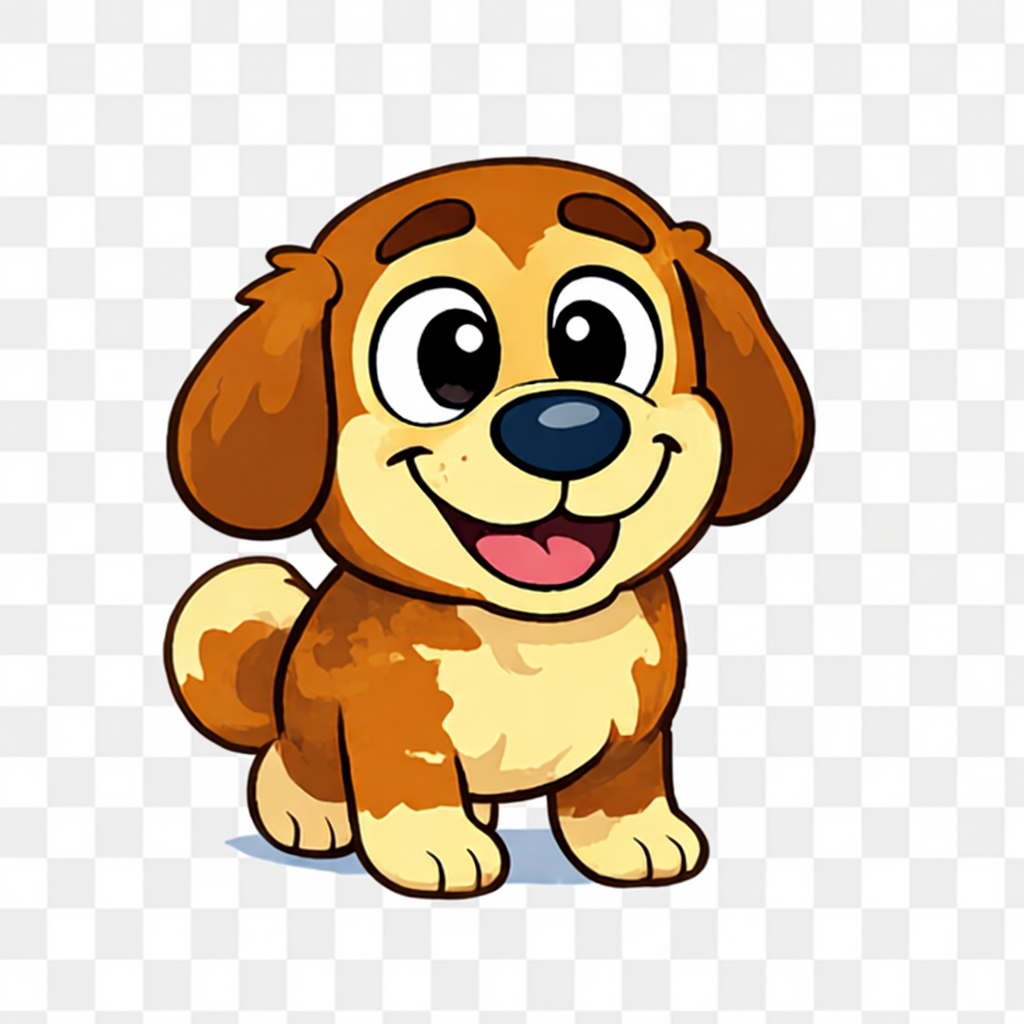

In [ ]:
from IPython.display import display
from PIL import Image
display(Image.open(output_file))

Training Script

In [ ]:
!pip install -q -U torchao==0.17.0
!pip install -q -U diffusers transformers accelerate peft bitsandbytes sentencepiece prodigyopt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 30.5 MB/s eta 0:00:00


In [ ]:

# Download FLUX LoRA training script

!wget -O train_dreambooth_lora_flux.py https://raw.githubusercontent.com/huggingface/diffusers/main/examples/dreambooth/train_dreambooth_lora_flux.py

print("Training script downloaded!")


--2026-05-10 01:56:51--  https://raw.githubusercontent.com/huggingface/diffusers/main/examples/dreambooth/train_dreambooth_lora_flux.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 80875 (79K) [text/plain]
Saving to: ‘train_dreambooth_lora_flux.py’

train_dreambooth_lo 100%[===================>]  78.98K  --.-KB/s    in 0.004s  

2026-05-10 01:56:51 (17.9 MB/s) - ‘train_dreambooth_lora_flux.py’ saved [80875/80875]

Training script downloaded!


In [ ]:
!accelerate launch train_dreambooth_lora_flux.py \
  --pretrained_model_name_or_path="black-forest-labs/FLUX.1-dev" \
  --instance_data_dir="/content/drive/MyDrive/Independent Study ML Diffusion/training_data" \
  --output_dir="/content/drive/MyDrive/Independent Study ML Diffusion/my_cartoon_lora/lora_output_v2" \
  --mixed_precision="bf16" \
  --instance_prompt="frmcrtoon style cartoon character" \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --learning_rate=1e-4 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --max_train_steps=1500 \
  --rank=8 \
  --seed=42 \
  --checkpointing_steps=250 \
  --gradient_checkpointing \
  --use_8bit_adam

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
05/10/2026 02:15:34 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType

In [ ]:
!pip install -q bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 41.6 MB/s eta 0:00:00


In [ ]:
import os

training_dir = "/content/drive/MyDrive/Independent Study ML Diffusion/training_data"

for filename in os.listdir(training_dir):
    if filename.endswith(".txt"):
        os.remove(os.path.join(training_dir, filename))

print("All .txt caption files removed!")

All .txt caption files removed!


In [ ]:
!ls "/content/drive/MyDrive/Independent Study ML Diffusion/my_cartoon_lora/"

lora_output  lora_output_v2


In [ ]:

# Step 2 — Save trained LoRA to Google Drive

import shutil

shutil.copytree(
    "lora_output_v2",
    "/content/drive/MyDrive/Independent Study ML Diffusion/my_cartoon_lora/lora_output_v2",
    dirs_exist_ok=True
)

print("LoRA saved to Drive!")

LoRA saved to Drive!


In [ ]:
# Step 3 — Load FLUX model

import torch
from diffusers import FluxPipeline

pipe = FluxPipeline.from_pretrained(
    "black-forest-labs/FLUX.1-dev",
    torch_dtype=torch.bfloat16
)

pipe.enable_model_cpu_offload()

print("FLUX Model loaded!")

Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

FLUX Model loaded!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!ls /content/drive/MyDrive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
'Colab Notebooks'		  'Independent Study ML Diffusion Model'
'HW3 wireshark.docx'		  'LS Direct Assessment'
'Independent Study ML Diffusion'   pa4-answers.docx


checkpoint-1000  checkpoint-250  logs
checkpoint-1250  checkpoint-500  pytorch_lora_weights.safetensors
checkpoint-1500  checkpoint-750


No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


  0%|          | 0/28 [00:00<?, ?it/s]

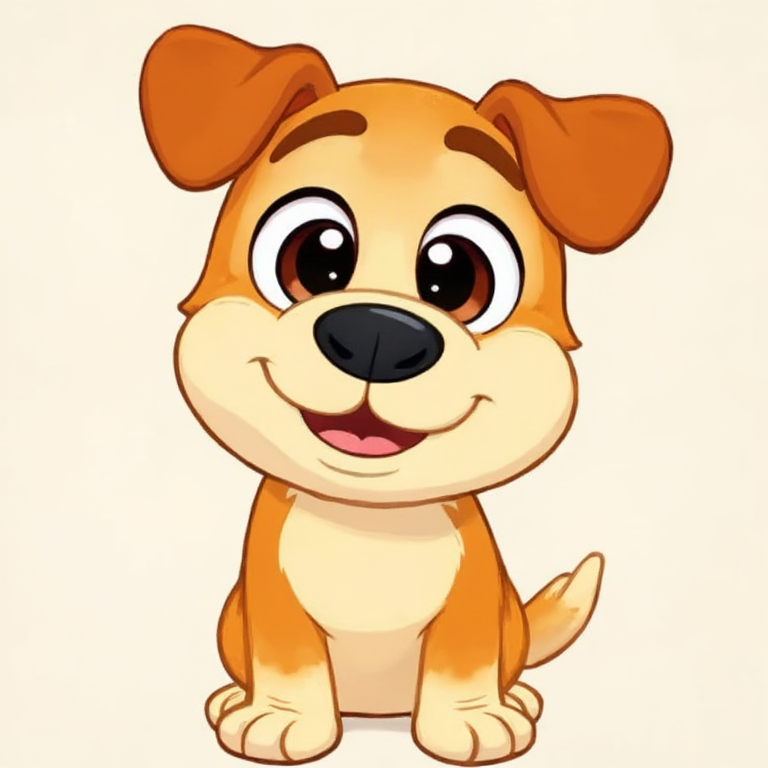

Done. Images saved to: /content/drive/MyDrive/Independent Study ML Diffusion/my_cartoon_lora/test_images


In [ ]:
# load lora after fLux is loaded


import torch
from IPython.display import display

# Your LoRA path
lora_path = "/content/drive/MyDrive/Independent Study ML Diffusion/my_cartoon_lora/lora_output_v2"

# Double check the folder exists
!ls "$lora_path"

# Load LoRA into your already-loaded FLUX pipeline
pipe.load_lora_weights(lora_path)

# Set LoRA strength
pipe.fuse_lora(lora_scale=0.8)

# Test prompts using your trigger word
prompts = [
    "frmcrtoon, cute cartoon dog character, clean animation style, simple background, high quality",

]

# Output folder
save_dir = "/content/drive/MyDrive/Independent Study ML Diffusion/my_cartoon_lora/test_images"
!mkdir -p "$save_dir"

# Generate and save images
for i, prompt in enumerate(prompts, start=1):
    image = pipe(
        prompt,
        height=768,
        width=768,
        guidance_scale=3.5,
        num_inference_steps=28,
        generator=torch.Generator("cuda").manual_seed(100 + i)
    ).images[0]

    display(image)
    image.save(f"{save_dir}/test_{i}.png")

print("Done. Images saved to:", save_dir)